In [27]:
import pandas as pd
import ast

In [79]:
df=pd.read_csv('inputs/VisionAPI_WLASL100/WLASL100_val_25fps.csv')

# lấy header
title=list(df.columns)
title.remove('video_size_height')
title.remove('video_size_width')
title.remove('video_fps')
title.remove('labels')

# Chuyển cột từ chuỗi sang list
for index, val in enumerate(title):
    df[val] = df[val].apply(ast.literal_eval)

In [73]:
def count_frame(row):
    count=[]
    for index, val in enumerate(title):
        count.append(len(row[val]))
    return set(count)

def dem_0_vao_cuoi(row, target_frames):
    for col in title:
        current_frames=row[col]
        padding = [0] * (target_frames-len(current_frames))

        row[col]+=padding

In [ ]:
for index, row in df.iterrows():
    count_frames=list(count_frame(row))
    if count_frames!=204:
        print(count_frames[0])

In [80]:
for index, row in df.iterrows():
    dem_0_vao_cuoi(row, 204)

In [81]:
for index, row in df.iterrows():
    count_frames=list(count_frame(row))
    if count_frames[0]!=204:
        print(count_frames[0])

In [82]:
df.to_csv('wlasl100_val_padding_0.csv', index=False)

In [26]:
_1=[0.520902,0.520902,0.520902,0,0,0,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.520902,0.496065,0.482911,0.493291,0.507911,0.484245,0.477791,0.459485,0.441084,0.41259,0.385504,0.268533,0,0,0,0,0.0289197]
_2=[0.430419,0.430419,0.430419,0,0,0,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.430419,0.442212,0.448338,0.426143,0.440351,0.413631,0.408111,0.408833,0.412923,0.413494,0.412733,0.40684,0,0,0,0,0.404998]
print(len(_1))
print(len(_2))

46
46


Dữ liệu gốc có 10 frame.
Mục tiêu: Đệm thành 204 frame.


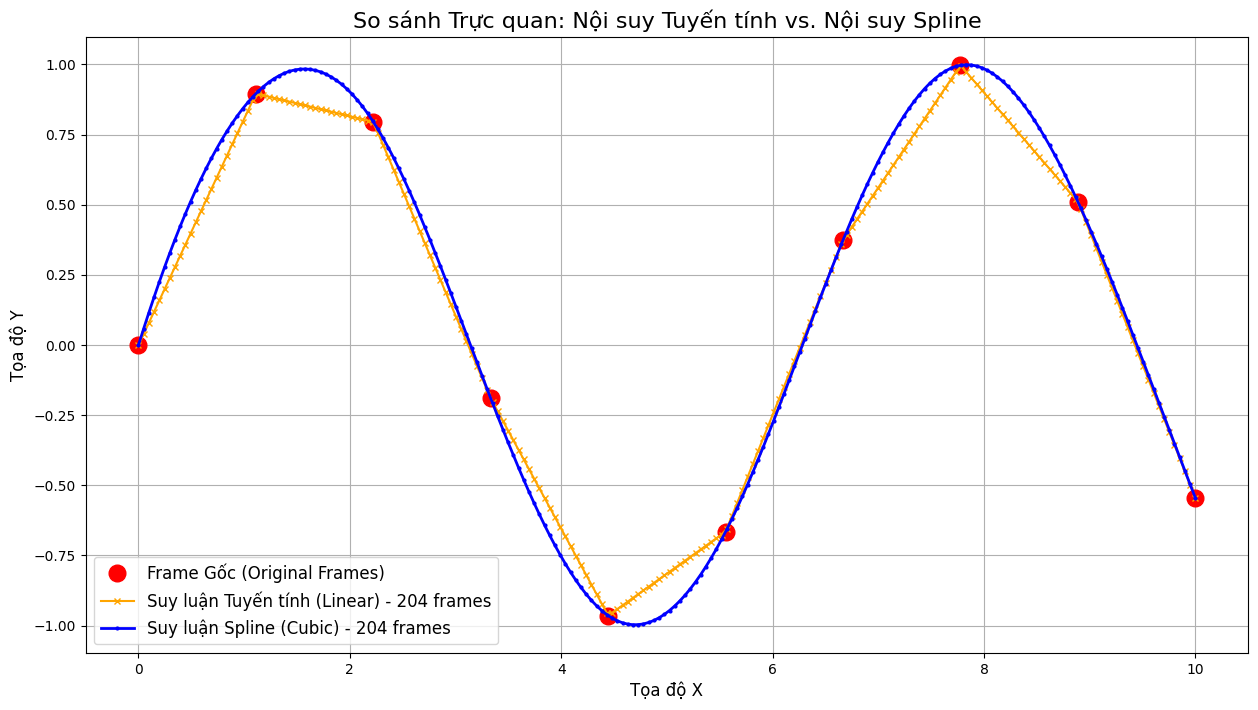

In [39]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# ==============================================================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU GỐC
# ==============================================================================
so_frame_goc = 10
target_frames = 204

# Tạo quỹ đạo cong (hình sin) để thấy rõ sự khác biệt
original_time_axis = np.linspace(0, 10, num=so_frame_goc)
original_keypoint_data = np.zeros((so_frame_goc, 2))
original_keypoint_data[:, 0] = original_time_axis # Tọa độ x đi thẳng
original_keypoint_data[:, 1] = np.sin(original_time_axis) # Tọa độ y đi hình sin

print(f"Dữ liệu gốc có {so_frame_goc} frame.")
print(f"Mục tiêu: Đệm thành {target_frames} frame.")

# ==============================================================================
# BƯỚC 2: THỰC HIỆN CẢ HAI PHƯƠNG PHÁP NỘI SUY
# ==============================================================================

# Tạo "trục thời gian" (chỉ số frame) mới cho dữ liệu 204 frame
new_time_axis = np.linspace(0, 10, num=target_frames)

# ---- 2.1. Nội suy Tuyến tính (Linear Interpolation) ----
# Tạo hàm nội suy tuyến tính
linear_interpolator_x = interp1d(original_time_axis, original_keypoint_data[:, 0], kind='linear')
linear_interpolator_y = interp1d(original_time_axis, original_keypoint_data[:, 1], kind='linear')
# Tạo dữ liệu mới
linear_padded_data = np.vstack((linear_interpolator_x(new_time_axis), linear_interpolator_y(new_time_axis))).T


# ---- 2.2. Nội suy Spline (Cubic Interpolation) ----
# Tạo hàm nội suy spline bậc 3
cubic_interpolator_x = interp1d(original_time_axis, original_keypoint_data[:, 0], kind='cubic')
cubic_interpolator_y = interp1d(original_time_axis, original_keypoint_data[:, 1], kind='cubic')
# Tạo dữ liệu mới
cubic_padded_data = np.vstack((cubic_interpolator_x(new_time_axis), cubic_interpolator_y(new_time_axis))).T


# ==============================================================================
# BƯỚC 3: TRỰC QUAN HÓA SO SÁNH
# ==============================================================================
plt.figure(figsize=(15, 8))

# 1. Vẽ các điểm gốc: To, rõ ràng, màu đỏ
plt.plot(original_keypoint_data[:, 0], original_keypoint_data[:, 1], 
         'o', color='red', markersize=12, label='Frame Gốc (Original Frames)')

# 2. Vẽ các điểm suy luận bằng Nội suy Tuyến tính: Nét gãy, màu cam
plt.plot(linear_padded_data[:, 0], linear_padded_data[:, 1], 
         'x-', color='orange', markersize=5, linewidth=1.5, 
         label=f'Suy luận Tuyến tính (Linear) - {target_frames} frames')

# 3. Vẽ các điểm suy luận bằng Nội suy Spline: Nét cong mượt, màu xanh
plt.plot(cubic_padded_data[:, 0], cubic_padded_data[:, 1], 
         '.-', color='blue', markersize=4, linewidth=2, 
         label=f'Suy luận Spline (Cubic) - {target_frames} frames')


# Thêm các chi tiết cho đồ thị
plt.title('So sánh Trực quan: Nội suy Tuyến tính vs. Nội suy Spline', fontsize=16)
plt.xlabel('Tọa độ X', fontsize=12)
plt.ylabel('Tọa độ Y', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

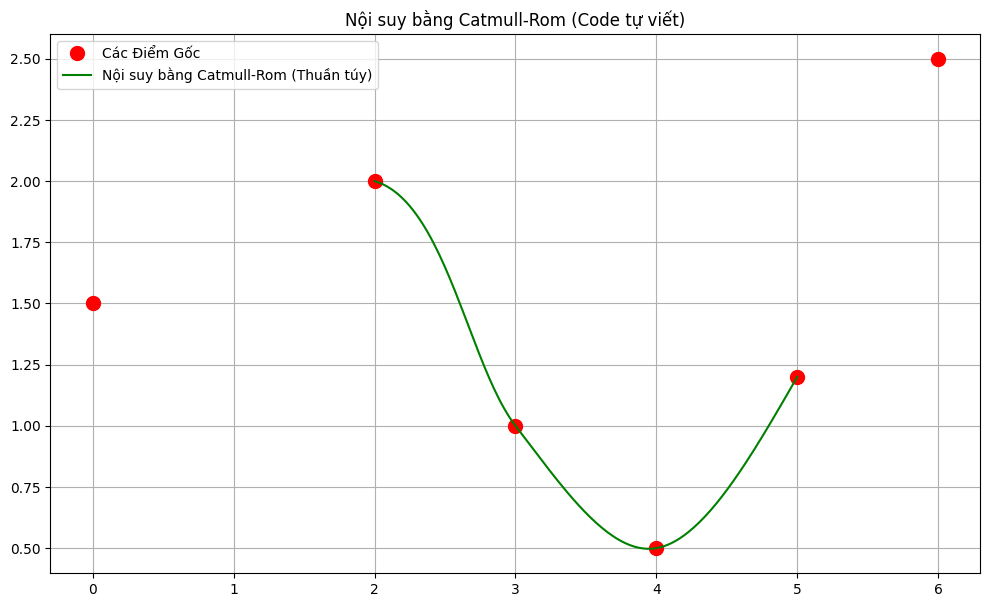

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Hàm định nghĩa công thức Catmull-Rom cho một đoạn
def catmull_rom_spline(P0, P1, P2, P3, num_points):
    """
    Tính toán các điểm trên đường cong Catmull-Rom giữa P1 và P2.
    P0, P1, P2, P3: là các điểm điều khiển (mỗi điểm là một mảng 1D, ví dụ: [x, y])
    num_points: số lượng điểm cần tạo ra trên đường cong.
    """
    # Chuyển thành mảng NumPy để tính toán vector
    P0, P1, P2, P3 = map(np.array, [P0, P1, P2, P3])
    
    # Tạo các giá trị t từ 0 đến 1
    t = np.linspace(0, 1, num_points)
    
    # Công thức Catmull-Rom
    # Q(t) = 0.5 * ( (2*P1) + (-P0 + P2)*t + (2*P0 - 5*P1 + 4*P2 - P3)*t^2 + (-P0 + 3*P1 - 3*P2 + P3)*t^3 )
    t2 = t**2
    t3 = t**3
    
    # Tính toán các hệ số của đa thức
    c0 = 2 * P1
    c1 = -P0 + P2
    c2 = 2 * P0 - 5 * P1 + 4 * P2 - P3
    c3 = -P0 + 3 * P1 - 3 * P2 + P3
    
    # Tính toán tọa độ các điểm trên đường cong
    # Sử dụng np.outer để nhân vector hệ số với mảng t
    points = 0.5 * (np.outer(c0, np.ones_like(t)) + 
                     np.outer(c1, t) + 
                     np.outer(c2, t2) + 
                     np.outer(c3, t3))
                     
    return points.T # Chuyển vị để có shape (num_points, 2)


# Dữ liệu gốc (ví dụ với 4 điểm)
points = np.array([
    [0, 1.5],
    [2, 2.0],
    [3, 1.0],
    [4, 0.5],
    [5, 1.2],
    [6, 2.5]
])

# Nội suy
interpolated_points = []
num_points_per_segment = 50 # Số điểm tạo ra giữa mỗi cặp điểm gốc

# Lặp qua các đoạn cần nội suy (từ P1 đến Pn-2)
# Chúng ta cần 4 điểm (P0, P1, P2, P3) cho mỗi đoạn
for i in range(len(points) - 3):
    P0, P1, P2, P3 = points[i], points[i+1], points[i+2], points[i+3]
    segment_points = catmull_rom_spline(P0, P1, P2, P3, num_points_per_segment)
    interpolated_points.extend(segment_points)

interpolated_points = np.array(interpolated_points)

# Vẽ đồ thị
plt.figure(figsize=(12, 7))
plt.plot(points[:, 0], points[:, 1], 'o', color='red', markersize=10, label='Các Điểm Gốc')
plt.plot(interpolated_points[:, 0], interpolated_points[:, 1], '-', color='green', label='Nội suy bằng Catmull-Rom (Thuần túy)')
plt.title('Nội suy bằng Catmull-Rom (Code tự viết)')
plt.legend()
plt.grid(True)
plt.show()

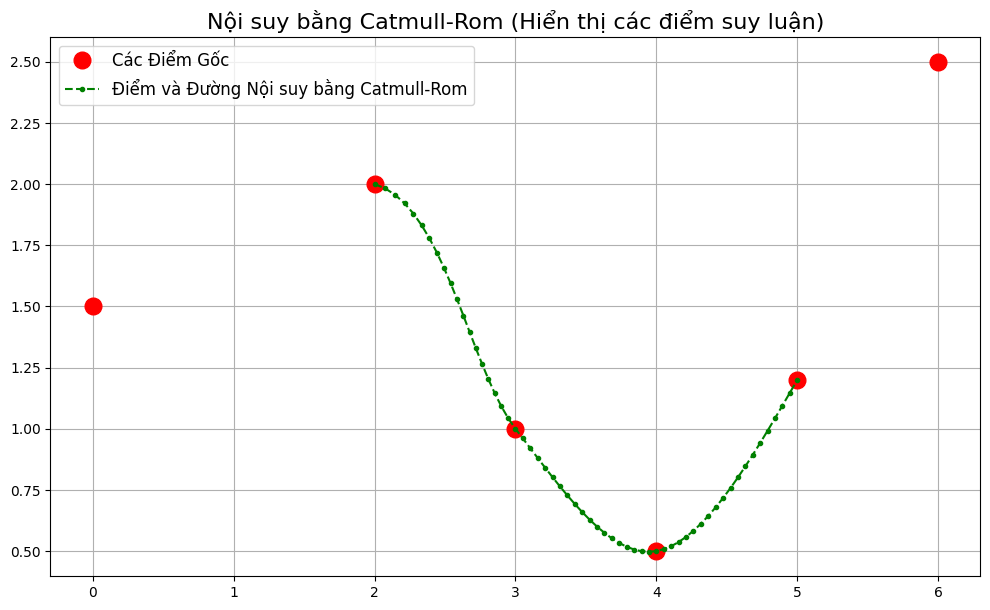

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Hàm định nghĩa công thức Catmull-Rom cho một đoạn
def catmull_rom_spline(P0, P1, P2, P3, num_points):
    """
    Tính toán các điểm trên đường cong Catmull-Rom giữa P1 và P2.
    P0, P1, P2, P3: là các điểm điều khiển (mỗi điểm là một mảng 1D, ví dụ: [x, y])
    num_points: số lượng điểm cần tạo ra trên đường cong.
    """
    # Chuyển thành mảng NumPy để tính toán vector
    P0, P1, P2, P3 = map(np.array, [P0, P1, P2, P3])
    
    # Tạo các giá trị t từ 0 đến 1
    t = np.linspace(0, 1, num_points)
    
    # Công thức Catmull-Rom
    # Q(t) = 0.5 * ( (2*P1) + (-P0 + P2)*t + (2*P0 - 5*P1 + 4*P2 - P3)*t^2 + (-P0 + 3*P1 - 3*P2 + P3)*t^3 )
    t2 = t**2
    t3 = t**3
    
    # Tính toán các hệ số của đa thức
    c0 = 2 * P1
    c1 = -P0 + P2
    c2 = 2 * P0 - 5 * P1 + 4 * P2 - P3
    c3 = -P0 + 3 * P1 - 3 * P2 + P3
    
    # Tính toán tọa độ các điểm trên đường cong
    # Sử dụng np.outer để nhân vector hệ số với mảng t
    points = 0.5 * (np.outer(c0, np.ones_like(t)) + 
                     np.outer(c1, t) + 
                     np.outer(c2, t2) + 
                     np.outer(c3, t3))
                     
    return points.T # Chuyển vị để có shape (num_points, 2)


# Dữ liệu gốc (ví dụ với 4 điểm)
points = np.array([
    [0, 1.5],
    [2, 2.0],
    [3, 1.0],
    [4, 0.5],
    [5, 1.2],
    [6, 2.5]
])

# Nội suy
interpolated_points = []
num_points_per_segment = 20 # Giảm số điểm để các điểm vẽ ra không bị quá dày đặc

# Lặp qua các đoạn cần nội suy (từ P1 đến Pn-2)
# Chúng ta cần 4 điểm (P0, P1, P2, P3) cho mỗi đoạn
for i in range(len(points) - 3):
    P0, P1, P2, P3 = points[i], points[i+1], points[i+2], points[i+3]
    segment_points = catmull_rom_spline(P0, P1, P2, P3, num_points_per_segment)
    # Không thêm điểm cuối cùng của đoạn để tránh trùng lặp với điểm đầu của đoạn sau
    interpolated_points.extend(segment_points[:-1]) 
    
# Thêm đoạn cuối cùng vào
interpolated_points.append(points[-2])

interpolated_points = np.array(interpolated_points)

# Vẽ đồ thị
plt.figure(figsize=(12, 7))

# Vẽ các điểm gốc
plt.plot(points[:, 0], points[:, 1], 'o', color='red', markersize=12, label='Các Điểm Gốc')

# *** THAY ĐỔI Ở ĐÂY ***
# Vẽ cả điểm và đường nối cho các điểm được nội suy
plt.plot(interpolated_points[:, 0], interpolated_points[:, 1], 
         '.--', # '.' để vẽ điểm, '--' để vẽ đường nối nét đứt
         color='green', 
         markersize=6, # Kích thước của điểm nội suy
         linewidth=1.5, # Độ dày đường nối
         label='Điểm và Đường Nội suy bằng Catmull-Rom')

plt.title('Nội suy bằng Catmull-Rom (Hiển thị các điểm suy luận)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [56]:
title

['indexMCP_right_X',
 'middleMCP_left_X',
 'ringPIP_right_Y',
 'thumbIP_left_X',
 'ringDIP_left_Y',
 'littleMCP_right_Y',
 'indexDIP_right_Y',
 'thumbCMC_left_Y',
 'thumbCMC_right_Y',
 'middleTip_right_Y',
 'middleDIP_left_X',
 'leftElbow_Y',
 'littleTip_right_X',
 'middleDIP_right_Y',
 'wrist_right_Y',
 'rightEye_X',
 'middleTip_left_X',
 'wrist_left_X',
 'leftEye_Y',
 'rightShoulder_Y',
 'littleTip_left_Y',
 'root_X',
 'middleDIP_right_X',
 'littleTip_right_Y',
 'indexTip_left_X',
 'littlePIP_right_Y',
 'indexDIP_left_Y',
 'indexMCP_left_Y',
 'thumbCMC_right_X',
 'littleTip_left_X',
 'thumbCMC_left_X',
 'middlePIP_right_Y',
 'indexDIP_left_X',
 'littleMCP_left_X',
 'indexTip_right_Y',
 'ringMCP_right_Y',
 'ringDIP_left_X',
 'thumbMP_left_X',
 'root_Y',
 'middleMCP_right_X',
 'neck_Y',
 'rightEye_Y',
 'nose_X',
 'rightShoulder_X',
 'thumbTip_right_Y',
 'ringMCP_left_X',
 'rightWrist_X',
 'leftElbow_X',
 'ringPIP_left_Y',
 'leftWrist_Y',
 'ringDIP_right_Y',
 'littlePIP_right_X',
 'midd

In [58]:
import pandas as pd
import numpy as np
import ast # Thư viện để chuyển đổi chuỗi thành list một cách an toàn
import os

# --- CÁC BIẾN CẤU HÌNH ---
INPUT_FILE = "inputs/VisionAPI_WLASL100/WLASL100_test_25fps - Copy.csv"
OUTPUT_FILE = "padded_videos.csv"
TARGET_FRAMES = 204
# Liệt kê tất cả các cột mà bạn muốn đệm
COLUMNS_TO_PAD = title

 
def pad_lists_in_dataframe(input_path, output_path, target_length, columns_to_process):
    """
    Đọc một file CSV, đệm 0 vào cuối các list trong các ô được chỉ định
    để chúng đạt đến độ dài mục tiêu.
    """
    print("\n--- Bắt đầu quá trình xử lý ---")
    
    # --- Bước 1: Đọc file CSV và chuyển đổi string thành list ---
    try:
        # Tạo một dictionary converter để áp dụng ast.literal_eval cho các cột cần thiết
        converters = {col: ast.literal_eval for col in columns_to_process}
        df = pd.read_csv(input_path, converters=converters)
        print("Đọc và chuyển đổi kiểu dữ liệu thành công!")
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file '{input_path}'")
        return
    except (ValueError, SyntaxError) as e:
        print(f"Lỗi khi chuyển đổi dữ liệu từ chuỗi sang list: {e}")
        print("Vui lòng kiểm tra định dạng dữ liệu trong file CSV.")
        return

    # --- Bước 2: Áp dụng logic đệm 0 cho từng hàng ---
    print(f"Đang đệm các list để có độ dài là {target_length}...")
    
    # Lặp qua từng hàng của DataFrame
    for index, row in df.iterrows():
        # Lặp qua từng cột cần xử lý trong hàng đó
        for col in columns_to_process:
            current_list = row[col]
            current_len = len(current_list)
            
            # Chỉ đệm nếu list hiện tại ngắn hơn độ dài mục tiêu
            if current_len < target_length:
                # Tính số lượng số 0 cần đệm
                num_to_pad = target_length - current_len
                
                # Tạo list chứa các số 0 và nối vào cuối list cũ
                padding = [0] * num_to_pad
                df.at[index, col] = current_list + padding
            # Optional: Nếu muốn cắt bớt list dài hơn target, thêm logic ở đây
            # elif current_len > target_length:
            #     df.at[index, col] = current_list[:target_length]

    print("Quá trình đệm hoàn tất!")

    # --- Bước 3: Lưu DataFrame đã xử lý ra file CSV mới ---
    df.to_csv(output_path, index=False)
    print(f"Đã lưu kết quả vào file: '{output_path}'")


# ==============================================================================
# CHẠY KỊCH BẢN
# ==============================================================================
if __name__ == "__main__":
    # 1. Tạo file dữ liệu mẫu
    # create_sample_csv(INPUT_FILE, COLUMNS_TO_PAD)

    # 2. Chạy hàm xử lý chính
    pad_lists_in_dataframe(
        input_path=INPUT_FILE,
        output_path=OUTPUT_FILE,
        target_length=TARGET_FRAMES,
        columns_to_process=COLUMNS_TO_PAD
    )

    # 3. Kiểm tra kết quả
    print("\n--- Kiểm tra file output ---")
    # Đọc lại file kết quả để xác minh
    df_result = pd.read_csv(OUTPUT_FILE, converters={col: ast.literal_eval for col in COLUMNS_TO_PAD})
    
    # Kiểm tra video đầu tiên (đáng lẽ đã được đệm)
    video_1_list = df_result.iloc[0][COLUMNS_TO_PAD[0]]
    print(f"Độ dài list của video_1 sau khi đệm: {len(video_1_list)}")
    print(f"5 giá trị cuối của list: {video_1_list[-5:]}")
    
    # Kiểm tra video thứ hai (đáng lẽ không thay đổi)
    video_2_list = df_result.iloc[1][COLUMNS_TO_PAD[0]]
    print(f"\nĐộ dài list của video_2 (không đệm): {len(video_2_list)}")

    # Dọn dẹp file tạm
    os.remove(INPUT_FILE)
    os.remove(OUTPUT_FILE)


--- Bắt đầu quá trình xử lý ---
Đọc và chuyển đổi kiểu dữ liệu thành công!
Đang đệm các list để có độ dài là 204...
Quá trình đệm hoàn tất!
Đã lưu kết quả vào file: 'padded_videos.csv'

--- Kiểm tra file output ---
Độ dài list của video_1 sau khi đệm: 204
5 giá trị cuối của list: [0, 0, 0, 0, 0]

Độ dài list của video_2 (không đệm): 204


PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'inputs/VisionAPI_WLASL100/WLASL100_test_25fps - Copy.csv'